# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The BNPL Financial Default Risk Dataset](https://www.kaggle.com/datasets/itzzomkar/buy-now-pay-later-bnpl-default-risk)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('BNPL_Financial_Default_Risk_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Customer_ID,Age,Employment_Status,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Late_Payment_History,Shopping_Category_Most_Frequent,Average_Transaction_Value_USD,Default_Risk
0,C00001,29,Employed,73405.0,637.0,2,193,No,Fashion,118,Low
1,C00002,64,Employed,53732.0,815.0,0,0,No,Electronics,662,Low
2,C00003,26,Freelancer,69930.0,723.0,2,273,No,Fashion,76,Low
3,C00004,19,Employed,96941.0,716.0,3,421,No,Home/Furniture,449,Low
4,C00005,55,Student,15959.0,675.0,2,145,No,Travel,974,Low


## last Five row

In [4]:
df.tail()

,Customer_ID,Age,Employment_Status,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Late_Payment_History,Shopping_Category_Most_Frequent,Average_Transaction_Value_USD,Default_Risk
9995,C09996,21,Freelancer,5000.0,669.0,2,241,No,Electronics,720,Medium
9996,C09997,23,Employed,NaN,709.0,2,249,No,Electronics,652,Low
9997,C09998,44,Student,22309.0,NaN,2,235,No,Groceries/Essentials,69,Low
9998,C09999,30,Employed,62460.0,681.0,3,332,Yes,Fashion,180,Low
9999,C10000,38,Employed,78349.0,807.0,4,525,Yes,Fashion,46,Low


## Shape of our dataset

In [5]:
df.shape

(10000, 11)

## List out all columns

In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Employment_Status', 'Income_USD', 'Credit_Score',
       'Total_BNPL_Active_Loans', 'Total_BNPL_Debt_USD',
       'Late_Payment_History', 'Shopping_Category_Most_Frequent',
       'Average_Transaction_Value_USD', 'Default_Risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Customer_ID                         object
Age                                  int64
Employment_Status                   object
Income_USD                         float64
Credit_Score                       float64
Total_BNPL_Active_Loans              int64
Total_BNPL_Debt_USD                  int64
Late_Payment_History                object
Shopping_Category_Most_Frequent     object
Average_Transaction_Value_USD        int64
Default_Risk                        object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_ID                      10000 non-null  object 
 1   Age                              10000 non-null  int64  
 2   Employment_Status                10000 non-null  object 
 3   Income_USD                       9695 non-null   float64
 4   Credit_Score                     9702 non-null   float64
 5   Total_BNPL_Active_Loans          10000 non-null  int64  
 6   Total_BNPL_Debt_USD              10000 non-null  int64  
 7   Late_Payment_History             10000 non-null  object 
 8   Shopping_Category_Most_Frequent  10000 non-null  object 
 9   Average_Transaction_Value_USD    10000 non-null  int64  
 10  Default_Risk                     10000 non-null  object 
dtypes: float64(2), int64(4), object(5)
memory usage: 859.5+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Customer_ID                          0
Age                                  0
Employment_Status                    0
Income_USD                         305
Credit_Score                       298
Total_BNPL_Active_Loans              0
Total_BNPL_Debt_USD                  0
Late_Payment_History                 0
Shopping_Category_Most_Frequent      0
Average_Transaction_Value_USD        0
Default_Risk                         0
dtype: int64

## Handle Missing Value by mean

In [10]:
df['Income_USD'] = df['Income_USD'].fillna(df['Income_USD'].mean())
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].mean())

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Age,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Average_Transaction_Value_USD
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,34.248300,53981.142651,663.671408,2.317000,348.805100,331.807700
std,12.911441,29339.399108,75.077458,1.854469,315.096249,264.360624
min,18.000000,5000.000000,300.000000,0.000000,0.000000,10.000000
25%,23.000000,23182.000000,622.000000,1.000000,142.000000,98.000000
50%,31.000000,57015.000000,671.000000,2.000000,262.500000,294.500000
75%,43.000000,76482.250000,716.000000,3.000000,467.000000,515.000000
max,64.000000,139452.000000,850.000000,10.000000,2731.000000,1420.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

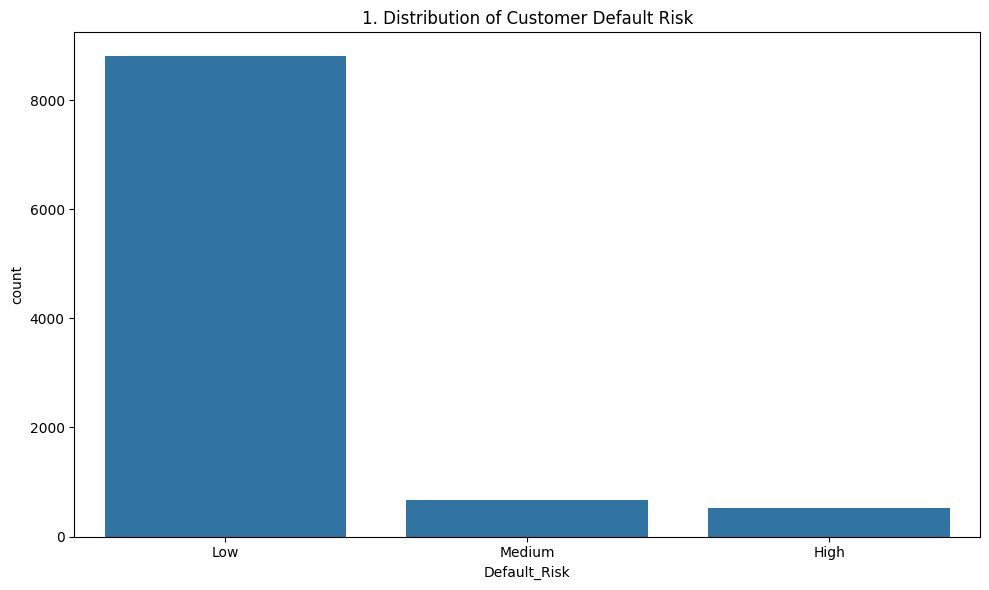

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Default_Risk')
plt.title(f'{plot_no}. Distribution of Customer Default Risk')
show_fig()
plot_no += 1

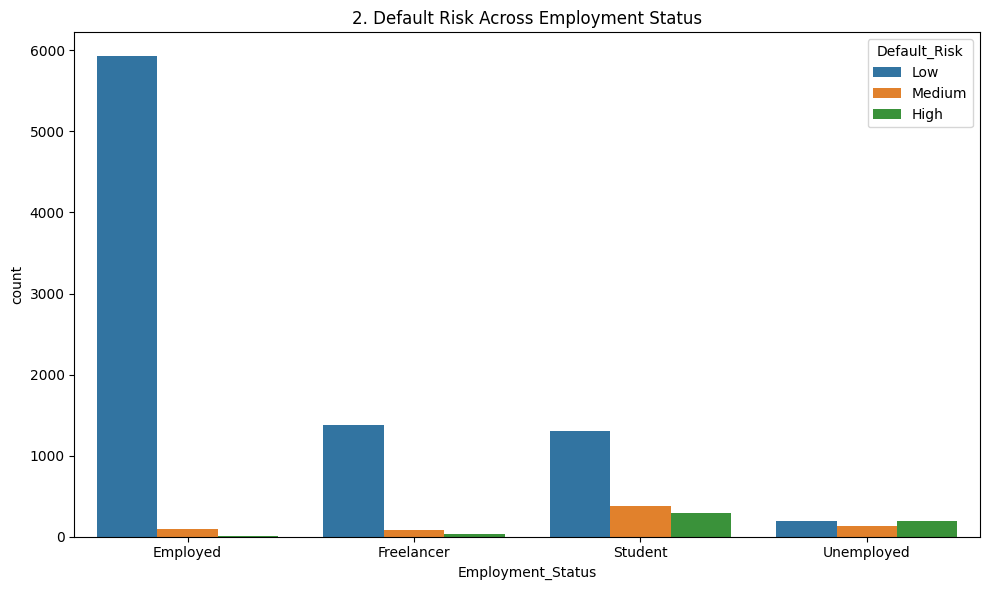

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Employment_Status', hue='Default_Risk')
plt.title(f'{plot_no}. Default Risk Across Employment Status')
show_fig()
plot_no += 1

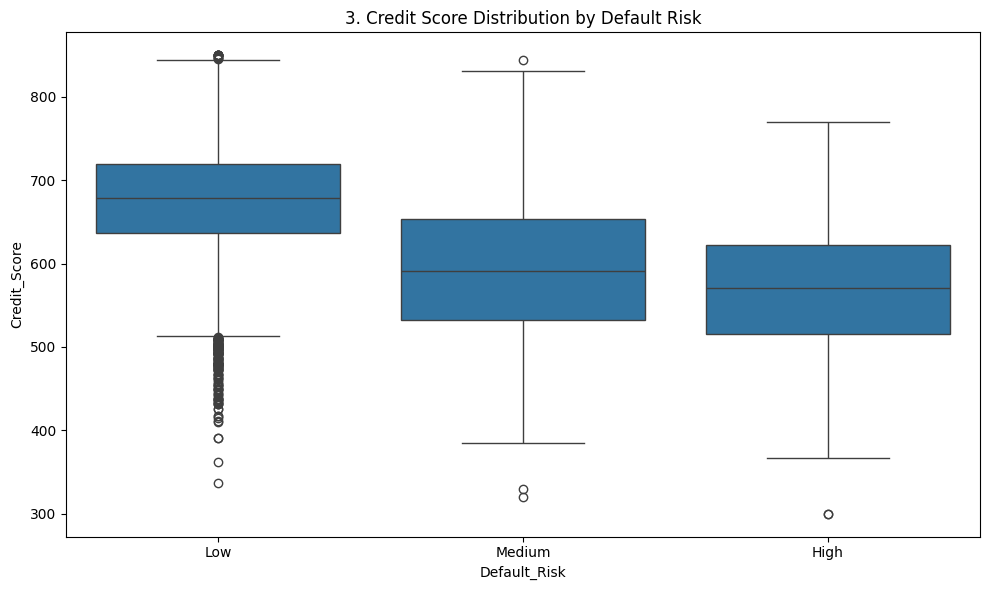

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Default_Risk', y='Credit_Score')
plt.title(f'{plot_no}. Credit Score Distribution by Default Risk')
show_fig()
plot_no += 1

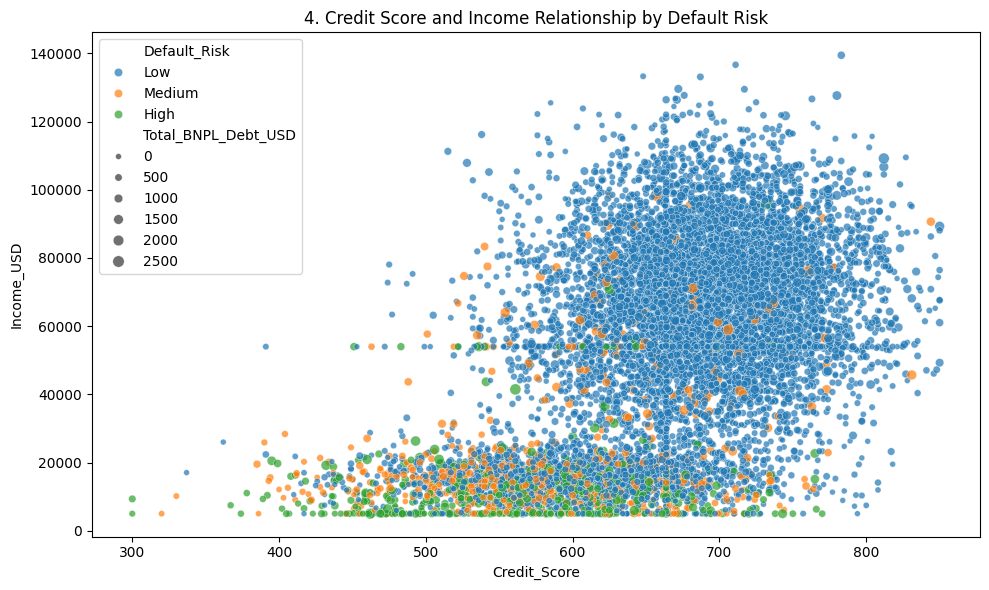

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Credit_Score', y='Income_USD', hue='Default_Risk', size='Total_BNPL_Debt_USD', alpha=0.7)
plt.title(f'{plot_no}. Credit Score and Income Relationship by Default Risk')
show_fig()
plot_no += 1

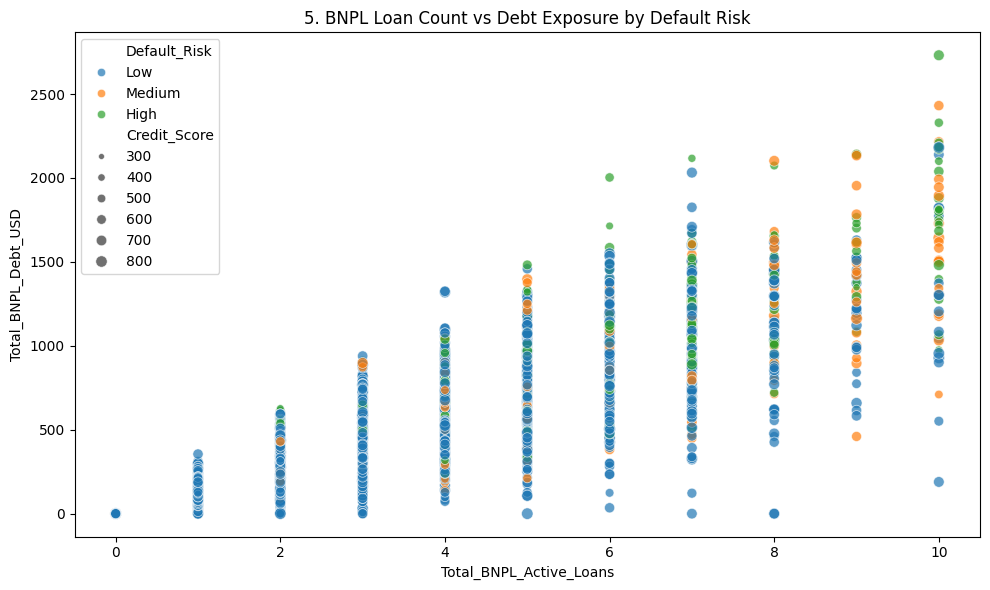

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total_BNPL_Active_Loans', y='Total_BNPL_Debt_USD', hue='Default_Risk', size='Credit_Score', alpha=0.7)
plt.title(f'{plot_no}. BNPL Loan Count vs Debt Exposure by Default Risk')
show_fig()
plot_no += 1

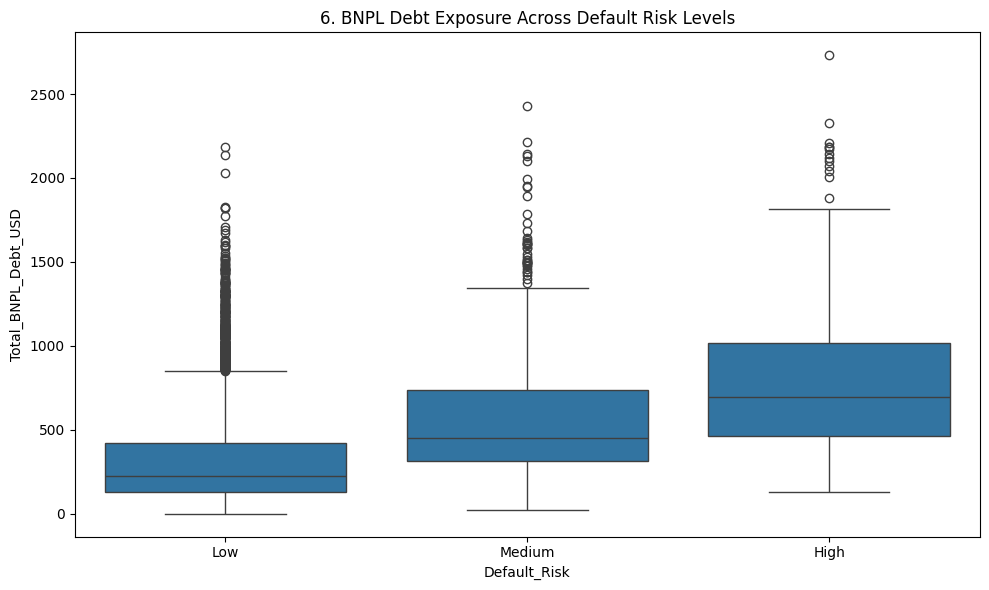

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Default_Risk', y='Total_BNPL_Debt_USD')
plt.title(f'{plot_no}. BNPL Debt Exposure Across Default Risk Levels')
show_fig()
plot_no += 1

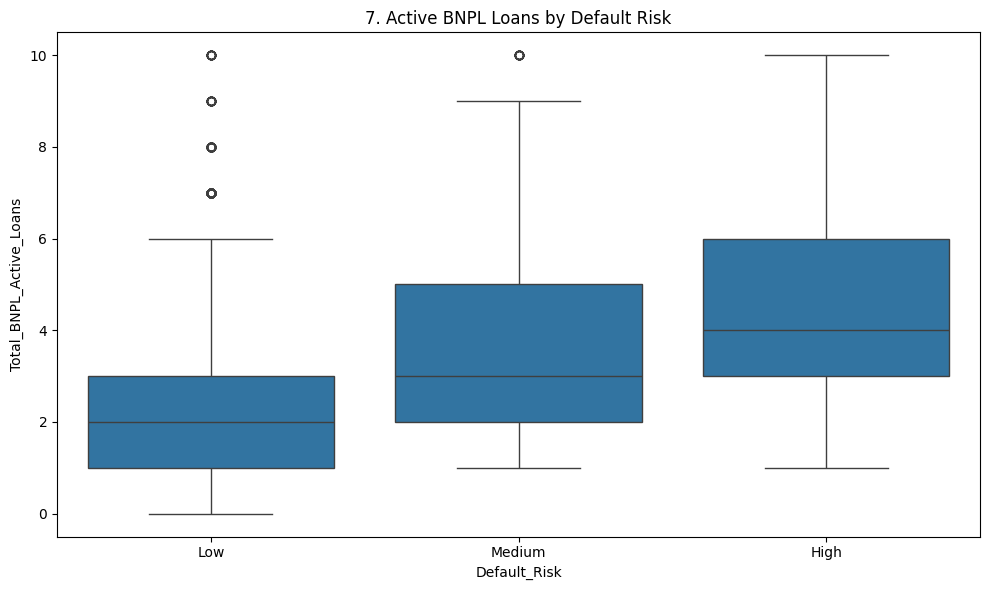

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Default_Risk', y='Total_BNPL_Active_Loans')
plt.title(f'{plot_no}. Active BNPL Loans by Default Risk')
show_fig()
plot_no += 1

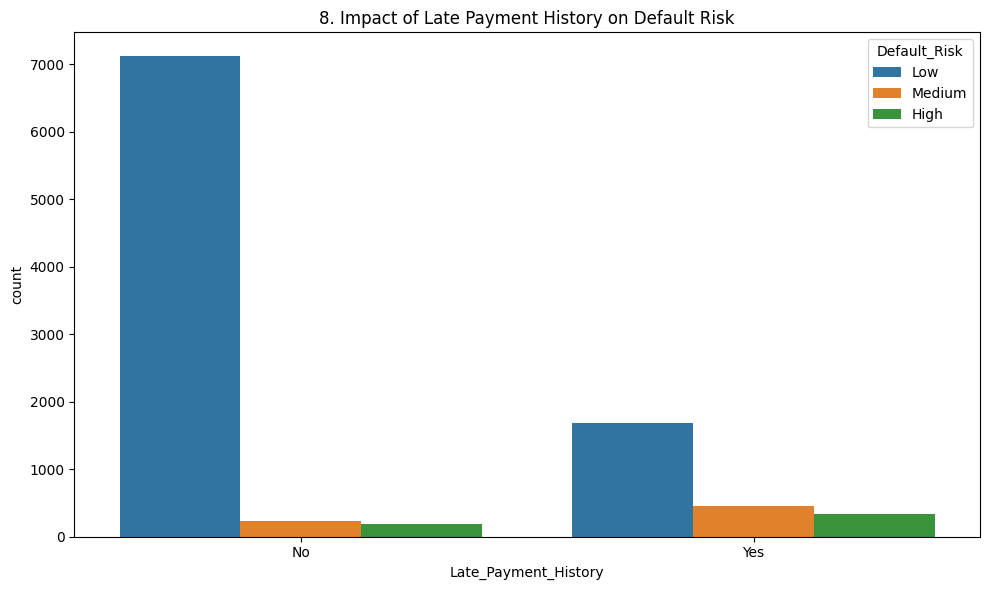

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Late_Payment_History', hue='Default_Risk')
plt.title(f'{plot_no}. Impact of Late Payment History on Default Risk')
show_fig()
plot_no += 1

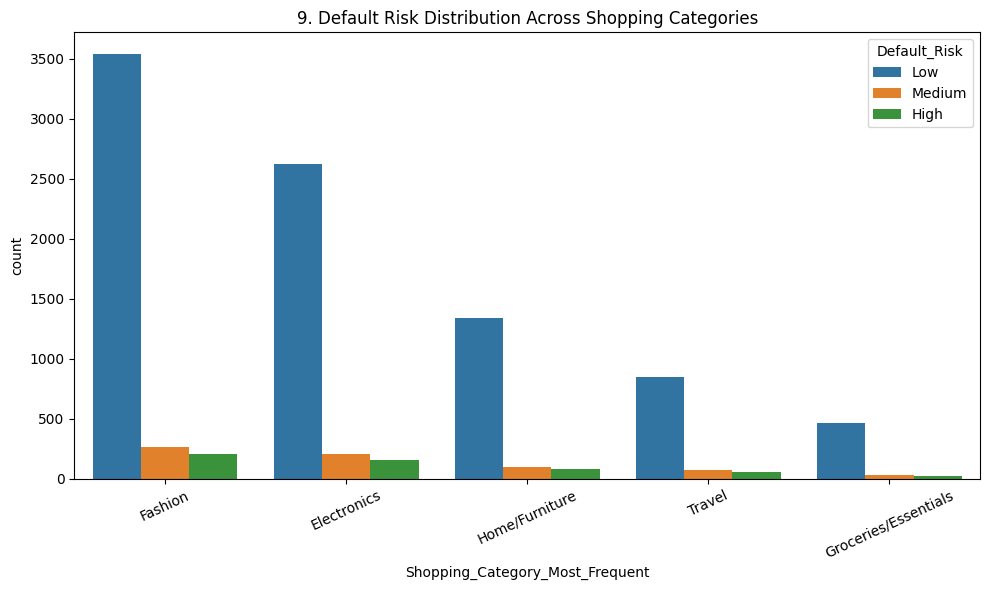

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Shopping_Category_Most_Frequent', hue='Default_Risk')
plt.title(f'{plot_no}. Default Risk Distribution Across Shopping Categories')
plt.xticks(rotation=25)
show_fig()
plot_no += 1

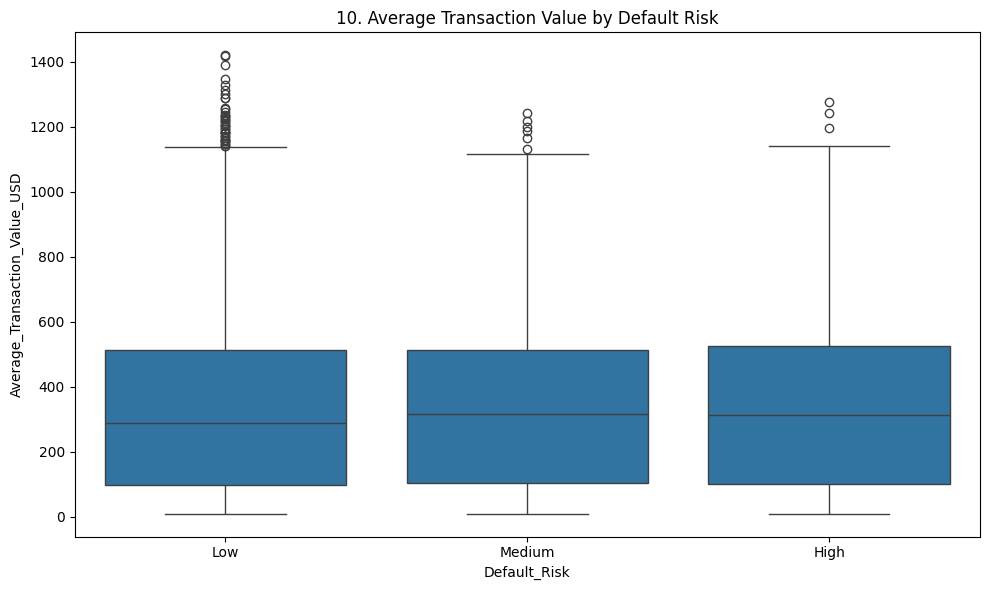

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Default_Risk', y='Average_Transaction_Value_USD')
plt.title(f'{plot_no}. Average Transaction Value by Default Risk')
show_fig()
plot_no += 1

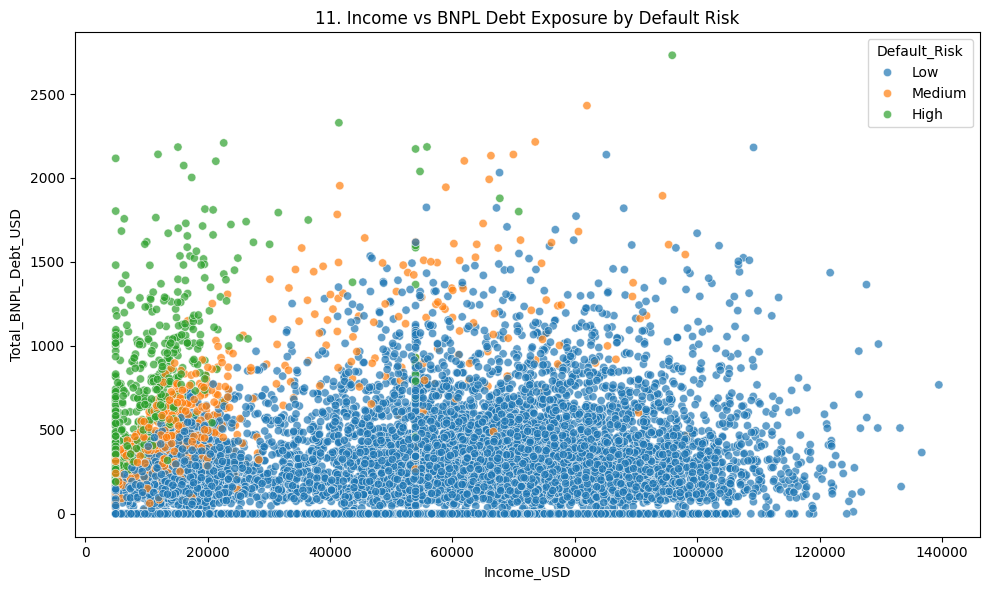

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Income_USD', y='Total_BNPL_Debt_USD', hue='Default_Risk', alpha=0.7)
plt.title(f'{plot_no}. Income vs BNPL Debt Exposure by Default Risk')
show_fig()
plot_no += 1

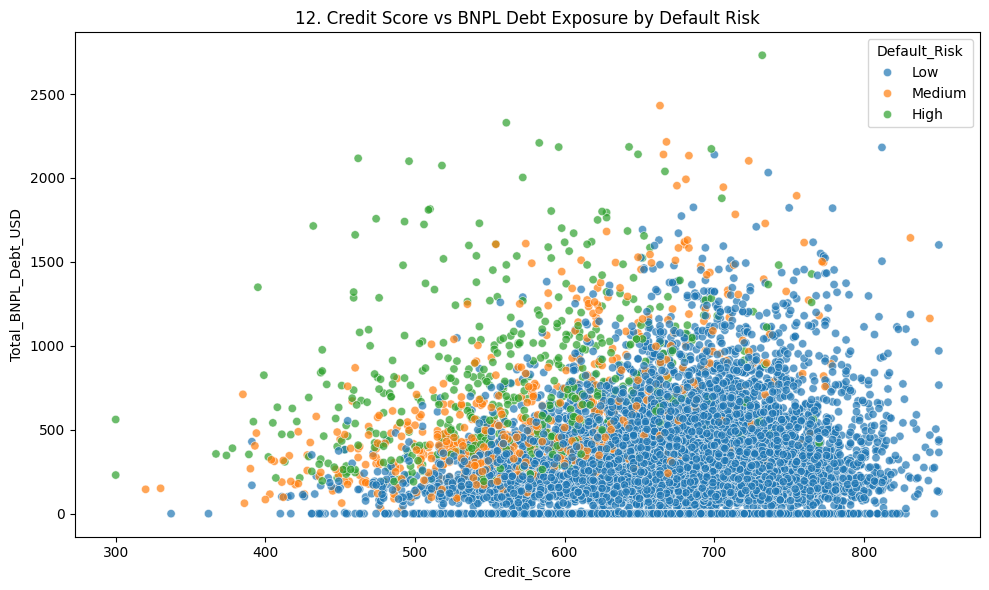

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Credit_Score', y='Total_BNPL_Debt_USD', hue='Default_Risk', alpha=0.7)
plt.title(f'{plot_no}. Credit Score vs BNPL Debt Exposure by Default Risk')
show_fig()
plot_no += 1

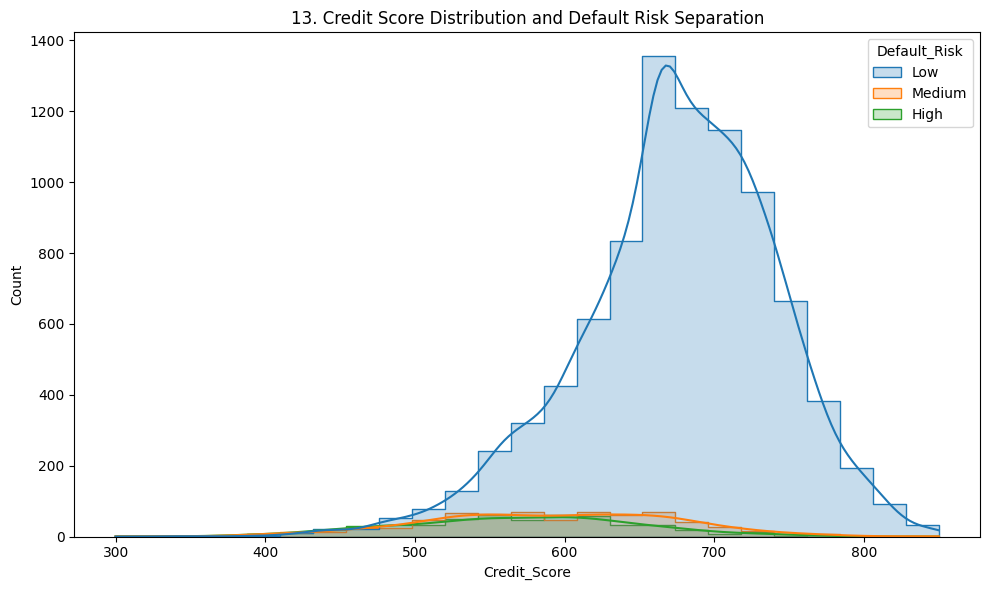

In [26]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Credit_Score', hue='Default_Risk', kde=True, bins=25, element='step')
plt.title(f'{plot_no}. Credit Score Distribution and Default Risk Separation')
show_fig()
plot_no += 1

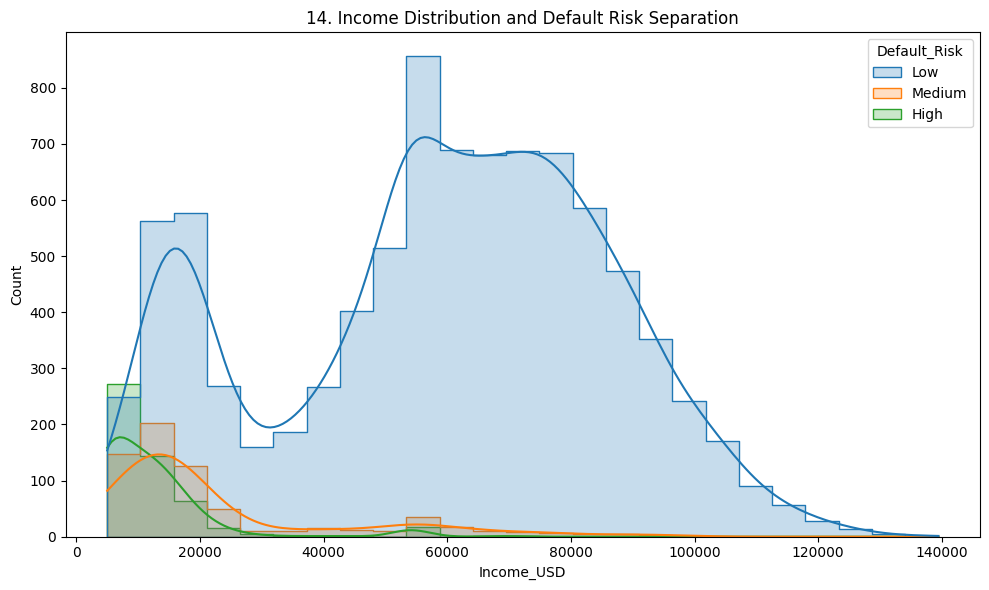

In [27]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Income_USD', hue='Default_Risk', kde=True, bins=25, element='step')
plt.title(f'{plot_no}. Income Distribution and Default Risk Separation')
show_fig()
plot_no += 1

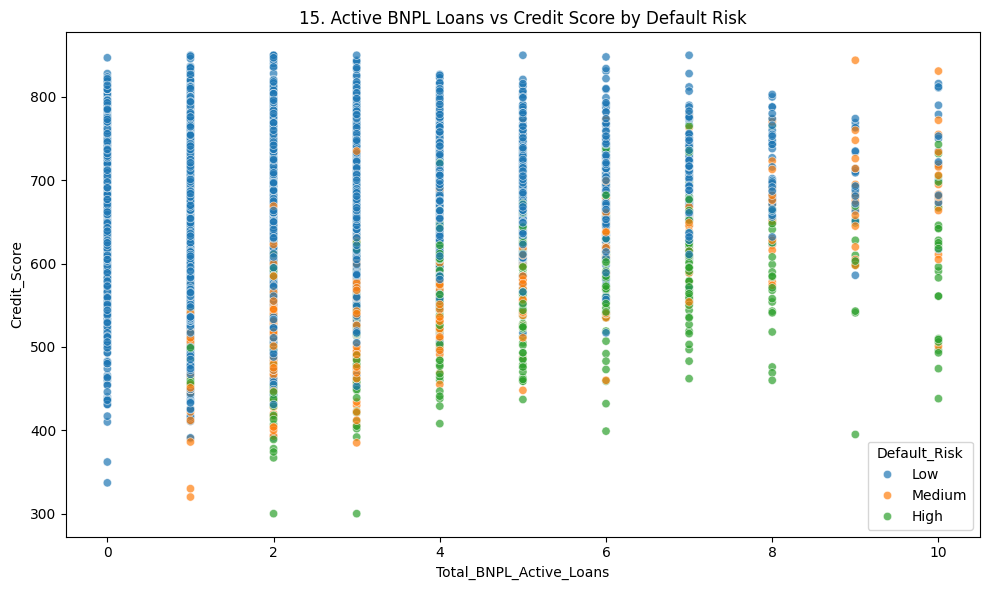

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total_BNPL_Active_Loans', y='Credit_Score', hue='Default_Risk', alpha=0.7)
plt.title(f'{plot_no}. Active BNPL Loans vs Credit Score by Default Risk')
show_fig()
plot_no += 1

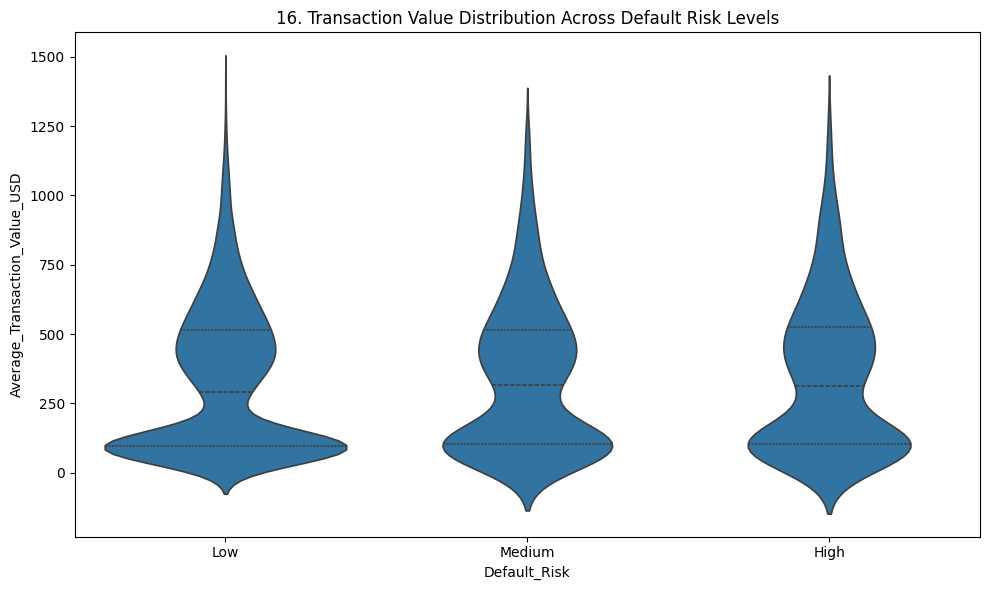

In [29]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Default_Risk', y='Average_Transaction_Value_USD', inner='quartile')
plt.title(f'{plot_no}. Transaction Value Distribution Across Default Risk Levels')
show_fig()
plot_no += 1

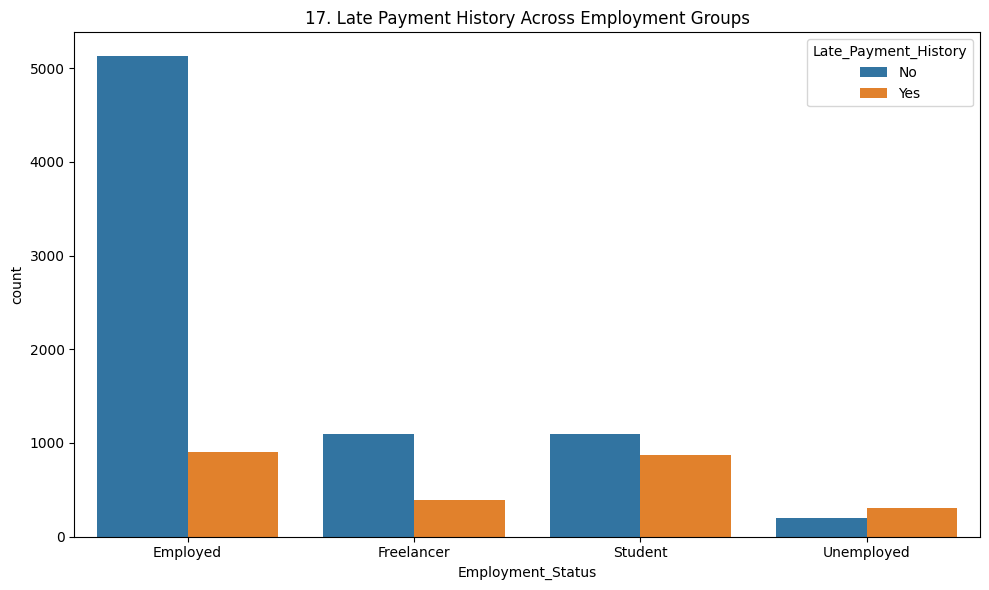

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Employment_Status', hue='Late_Payment_History')
plt.title(f'{plot_no}. Late Payment History Across Employment Groups')
show_fig()
plot_no += 1

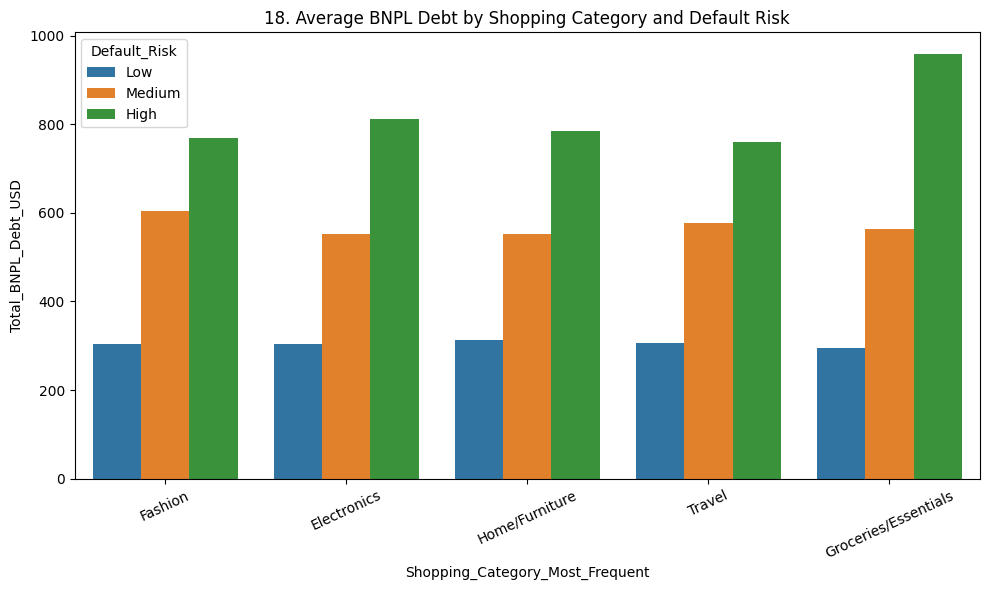

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Shopping_Category_Most_Frequent', y='Total_BNPL_Debt_USD', hue='Default_Risk', errorbar=None)
plt.title(f'{plot_no}. Average BNPL Debt by Shopping Category and Default Risk')
plt.xticks(rotation=25)
show_fig()
plot_no += 1

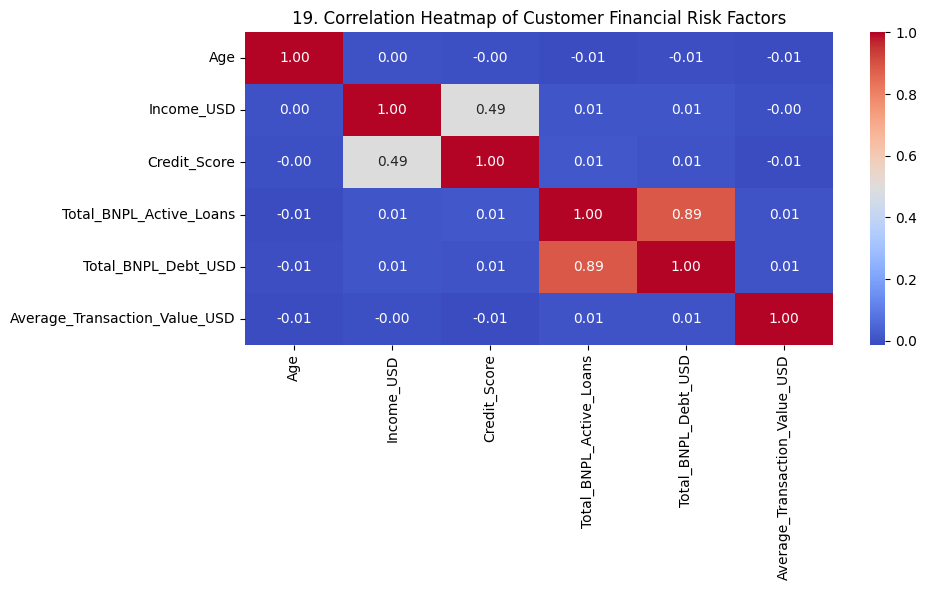

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Customer Financial Risk Factors')
show_fig()
plot_no += 1

# Model Training

## Define features and target

In [33]:
X = df.drop(columns=['Customer_ID', 'Default_Risk'])
y = df['Default_Risk']

## Separate numerical and categorical features

In [34]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns

## Preprocess numerical and categorical data

In [35]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

## Create Logistic Regression model

In [36]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

## Split dataset into training and testing data

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train the model

In [38]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions

In [39]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Accuracy Score: 0.9460
Accuracy Percentage: 94.60%


## Display classification report

In [41]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.81      0.82       104
         Low       0.98      0.98      0.98      1760
      Medium       0.63      0.60      0.61       136

    accuracy                           0.95      2000
   macro avg       0.81      0.79      0.80      2000
weighted avg       0.94      0.95      0.95      2000



## Create confusion matrix

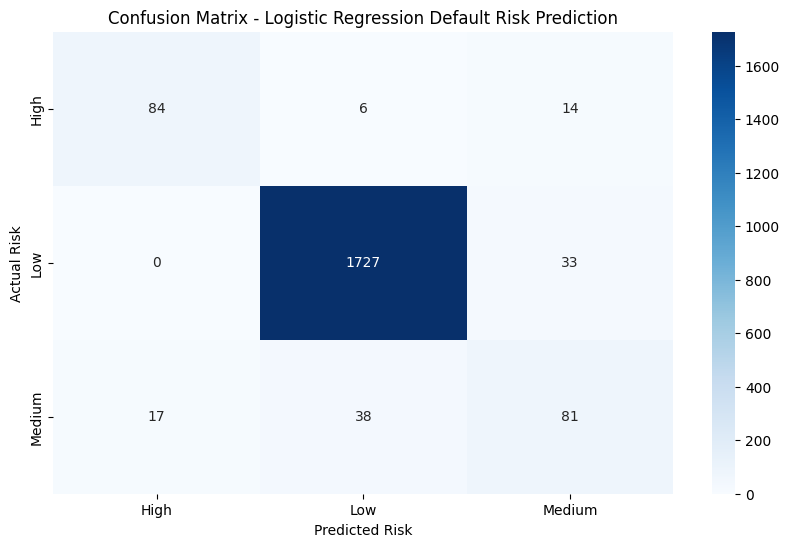

In [42]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig = plt.figure(figsize=(10, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel('Predicted Risk')
plt.ylabel('Actual Risk')
plt.title('Confusion Matrix - Logistic Regression Default Risk Prediction')
plt.show()